# U of T Waitlist Oracle - model-family screening

This notebook tests whether a model improves on the current historical percentage. All validation is chronological: complete offerings are kept together and no future session is allowed into training.

**Primary metric:** weighted Brier score (lower is better). Secondary metrics are log loss, calibration error, and ROC AUC. Accuracy is deliberately omitted because a probability can have good accuracy while being badly calibrated.

In [1]:
from __future__ import annotations

from pathlib import Path

import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()), cwd)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 4
SESSION_ORDER = ['20229', '20235', '20239', '20245', '20249', '20255', '20259', '20265']
paths = {session: CACHE_ROOT / f'{session}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for session in SESSION_ORDER}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in paths.items()}
for frame in session_samples.values():
    frame['days_rounded'] = frame['days_to_deadline'].round().astype('int16')
    frame['offering_id'] = frame['session'].astype(str) + ':' + frame['course_code'] + ':' + frame['meeting']
examples = pd.concat(session_samples.values(), ignore_index=True)
print(f'Loaded {len(examples):,} cached modelling rows')


Loaded 2,379,974 cached modelling rows


## 1. Load Notebook 1's canonical cache

All model families use the same deterministic per-session rows. This notebook performs no archive reconstruction and can be restarted without repeating data preparation.


## 2. Models and baselines

The intended UI baseline counts every prior lecture section of the same course as one observation. For each section across all prior sessions, select its snapshot nearest the requested days-to-deadline, exclude it if the waitlist never reached the requested position, and count one cleared/not-cleared vote. There are no course, lecture-number, term, or global fallbacks. Rows without any comparable prior lecture are excluded from head-to-head scoring.

Feature ablations answer whether recent movement, capacity context, and course identity improve out-of-time probabilities rather than merely fitting the archive.

In [2]:
CORE_NUMERIC = ['position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline']
MOVEMENT_NUMERIC = CORE_NUMERIC + ['movement_3d', 'movement_7d']
ALL_NUMERIC = MOVEMENT_NUMERIC + ['position', 'waitlist', 'capacity', 'capacity_changed_7d']
CATEGORICAL = ['course_code', 'campus', 'term']


def weighted_rate(frame: pd.DataFrame) -> float:
    return float(np.average(frame['cleared'], weights=frame['model_weight']))


def ui_history_predictions(train: pd.DataFrame, valid: pd.DataFrame) -> np.ndarray:
    result = pd.Series(np.nan, index=valid.index, dtype=float)
    for course_code, queries in valid.groupby('course_code', sort=False):
        history = train[train['course_code'].eq(course_code)]
        if history.empty:
            continue
        offerings = []
        for _, offering in history.groupby('offering_id', sort=False):
            by_position = {int(position): (rows['days_rounded'].to_numpy(), rows['cleared'].to_numpy()) for position, rows in offering.groupby('position', sort=False)}
            offerings.append(by_position)
        for (target_day, position), day_queries in queries.groupby(['days_rounded','position'], sort=False):
            outcomes = []
            for offering in offerings:
                trajectory = offering.get(int(position))
                if trajectory is not None:
                    days, cleared = trajectory
                    outcomes.append(cleared[np.abs(days - target_day).argmin()])
            if outcomes:
                result.loc[day_queries.index] = float(np.mean(outcomes))
    return result.to_numpy()


def logistic_pipeline(numeric: list[str], categorical: list[str] | None = None) -> Pipeline:
    categorical = categorical or []
    transformers = [
        ('numeric', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ]
    if categorical:
        transformers.append(('categorical', OneHotEncoder(handle_unknown='ignore', min_frequency=2), categorical))
    return Pipeline([
        ('features', ColumnTransformer(transformers)),
        ('model', LogisticRegression(max_iter=500, C=1.0)),
    ])


def boosted_pipeline() -> Pipeline:
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), ALL_NUMERIC),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=200, max_leaf_nodes=15, l2_regularization=1.0, random_state=42
        )),
    ])

## 3. Chronological rolling backtest

Each validation session is predicted using every completed session that chronologically precedes it. The 2025–26 Fall/Winter fold is our main holdout, but earlier folds reveal whether a result is stable across years.

In [3]:
SESSION_ORDER = ['20229', '20235', '20239', '20245', '20249', '20255', '20259', '20265']
VALIDATION_SESSIONS = ["20239", "20249", "20259", "20265"]
TRAIN_ROWS_PER_FOLD = 2_000_000

def expected_calibration_error(y_true, probability, weight, bins=10) -> float:
    table = pd.DataFrame({'y': y_true, 'p': probability, 'w': weight})
    table['bin'] = pd.cut(table['p'], bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    total_weight = table['w'].sum()
    error = 0.0
    for _, group in table.groupby('bin', observed=True):
        if group.empty:
            continue
        observed = np.average(group['y'], weights=group['w'])
        predicted = np.average(group['p'], weights=group['w'])
        error += group['w'].sum() / total_weight * abs(observed - predicted)
    return float(error)


def score_predictions(name, session, valid, probability) -> dict:
    y = valid['cleared'].to_numpy()
    w = valid['model_weight'].to_numpy()
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    return {
        'model': name,
        'validation_session': session,
        'offerings': valid['offering_id'].nunique(),
        'rows': len(valid),
        'brier': brier_score_loss(y, probability, sample_weight=w),
        'log_loss': log_loss(y, probability, sample_weight=w, labels=[0, 1]),
        'ece_10': expected_calibration_error(y, probability, w),
        'roc_auc': roc_auc_score(y, probability, sample_weight=w),
    }


model_factories = {
    'logistic_core': lambda: logistic_pipeline(CORE_NUMERIC),
    'logistic_movement': lambda: logistic_pipeline(MOVEMENT_NUMERIC),
    'logistic_all': lambda: logistic_pipeline(ALL_NUMERIC, CATEGORICAL),
    'boosted_numeric': boosted_pipeline,
}

scores, holdout_predictions = [], {}
for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    print(
        f"\n[{fold_number}/{len(VALIDATION_SESSIONS)}] Starting {valid_session}",
        flush=True,
    )

    valid_index = SESSION_ORDER.index(valid_session)
    train_sessions = SESSION_ORDER[:valid_index]
    train = examples[examples["session"].isin(train_sessions)]
    valid = examples[examples["session"] == valid_session]

    if train.empty or valid.empty or valid["cleared"].nunique() < 2:
        print("Skipped", flush=True)
        continue

    model_train = train.sample(
        n=min(TRAIN_ROWS_PER_FOLD, len(train)),
        random_state=42,
    )
    print(
        f"  Learned models: {len(model_train):,} training rows; "
        f"validation: {len(valid):,} rows",
        flush=True,
    )

    print("  Calculating historical baseline...", flush=True)
    ui_probability = ui_history_predictions(train, valid)
    print("  Historical baseline complete", flush=True)

    comparable = np.isfinite(ui_probability)
    valid_scored = valid.loc[comparable]
    if valid_scored.empty:
        continue

    coverage = valid_scored["model_weight"].sum() / valid["model_weight"].sum()
    scores.append({
        **score_predictions(
            "ui_history",
            valid_session,
            valid_scored,
            ui_probability[comparable],
        ),
        "coverage": coverage,
    })
    holdout_predictions[(valid_session, "ui_history")] = (
        valid_scored.index,
        ui_probability[comparable],
    )

    for name, factory in model_factories.items():
        print(f"  Training {name}...", flush=True)

        model = factory()
        features = (
            ALL_NUMERIC + CATEGORICAL if name == "logistic_all"
            else MOVEMENT_NUMERIC if name == "logistic_movement"
            else CORE_NUMERIC if name == "logistic_core"
            else ALL_NUMERIC
        )

        model.fit(
            model_train[features],
            model_train["cleared"],
            model__sample_weight=model_train["model_weight"],
        )

        probability = model.predict_proba(valid[features])[:, 1][comparable]
        scores.append({
            **score_predictions(name, valid_session, valid_scored, probability),
            "coverage": coverage,
        })
        holdout_predictions[(valid_session, name)] = (
            valid_scored.index,
            probability,
        )

        print(f"  {name} complete", flush=True)

    print(f"[{fold_number}/{len(VALIDATION_SESSIONS)}] {valid_session} complete", flush=True)

scores = pd.DataFrame(scores).sort_values(['validation_session', 'brier'])
scores


[1/4] Starting 20239
  Learned models: 579,974 training rows; validation: 300,000 rows
  Calculating historical baseline...
  Historical baseline complete
  Training logistic_core...
  logistic_core complete
  Training logistic_movement...
  logistic_movement complete
  Training logistic_all...
  logistic_all complete
  Training boosted_numeric...
  boosted_numeric complete
[1/4] 20239 complete

[2/4] Starting 20249
  Learned models: 1,179,974 training rows; validation: 300,000 rows
  Calculating historical baseline...
  Historical baseline complete
  Training logistic_core...
  logistic_core complete
  Training logistic_movement...
  logistic_movement complete
  Training logistic_all...
  logistic_all complete
  Training boosted_numeric...
  boosted_numeric complete
[2/4] 20249 complete

[3/4] Starting 20259
  Learned models: 1,779,974 training rows; validation: 300,000 rows
  Calculating historical baseline...
  Historical baseline complete
  Training logistic_core...
  logistic_cor

,model,validation_session,offerings,rows,brier,log_loss,ece_10,roc_auc,coverage
4,boosted_numeric,20239,2640,187422,0.044510,0.152022,0.019173,0.953341,0.526920
2,logistic_movement,20239,2640,187422,0.063616,0.231020,0.045097,0.904226,0.526920
1,logistic_core,20239,2640,187422,0.063808,0.232255,0.043984,0.904338,0.526920
3,logistic_all,20239,2640,187422,0.063885,0.224492,0.031613,0.898962,0.526920
0,ui_history,20239,2640,187422,0.103334,1.334196,0.101269,0.634247,0.526920
9,boosted_numeric,20249,3227,223560,0.047830,0.156543,0.023992,0.960086,0.644801
8,logistic_all,20249,3227,223560,0.064209,0.215889,0.031125,0.918074,0.644801
7,logistic_movement,20249,3227,223560,0.067890,0.234122,0.044011,0.908452,0.644801
6,logistic_core,20249,3227,223560,0.068138,0.235378,0.045898,0.907844,0.644801
5,ui_history,20249,3227,223560,0.097236,1.122779,0.082539,0.702155,0.644801


In [4]:
scores = pd.DataFrame(scores).sort_values(
    ["validation_session", "brier"]
).reset_index(drop=True)

print(f"{len(scores)} results")
display(scores)

20 results


,model,validation_session,offerings,rows,brier,log_loss,ece_10,roc_auc,coverage
0,boosted_numeric,20239,2640,187422,0.044510,0.152022,0.019173,0.953341,0.526920
1,logistic_movement,20239,2640,187422,0.063616,0.231020,0.045097,0.904226,0.526920
2,logistic_core,20239,2640,187422,0.063808,0.232255,0.043984,0.904338,0.526920
3,logistic_all,20239,2640,187422,0.063885,0.224492,0.031613,0.898962,0.526920
4,ui_history,20239,2640,187422,0.103334,1.334196,0.101269,0.634247,0.526920
5,boosted_numeric,20249,3227,223560,0.047830,0.156543,0.023992,0.960086,0.644801
6,logistic_all,20249,3227,223560,0.064209,0.215889,0.031125,0.918074,0.644801
7,logistic_movement,20249,3227,223560,0.067890,0.234122,0.044011,0.908452,0.644801
8,logistic_core,20249,3227,223560,0.068138,0.235378,0.045898,0.907844,0.644801
9,ui_history,20249,3227,223560,0.097236,1.122779,0.082539,0.702155,0.644801


## 4. Compare stability and calibration

A candidate should beat `ui_history` on the same comparable rows, both on average and on the main `20259` holdout, without a materially worse calibration error. Coverage reports what fraction of validation offering-weight the current UI can score at all. A tiny improvement confined to one session is not enough.

,mean_brier,worst_brier,mean_log_loss,mean_ece,mean_auc
model,,,,,
boosted_numeric,0.046554,0.052653,0.161510,0.022857,0.945099
logistic_all,0.062462,0.064209,0.211346,0.030761,0.913290
logistic_movement,0.064206,0.067890,0.224289,0.040621,0.903871
logistic_core,0.064334,0.068138,0.225148,0.040566,0.903839
ui_history,0.094924,0.103334,1.098086,0.083197,0.679461


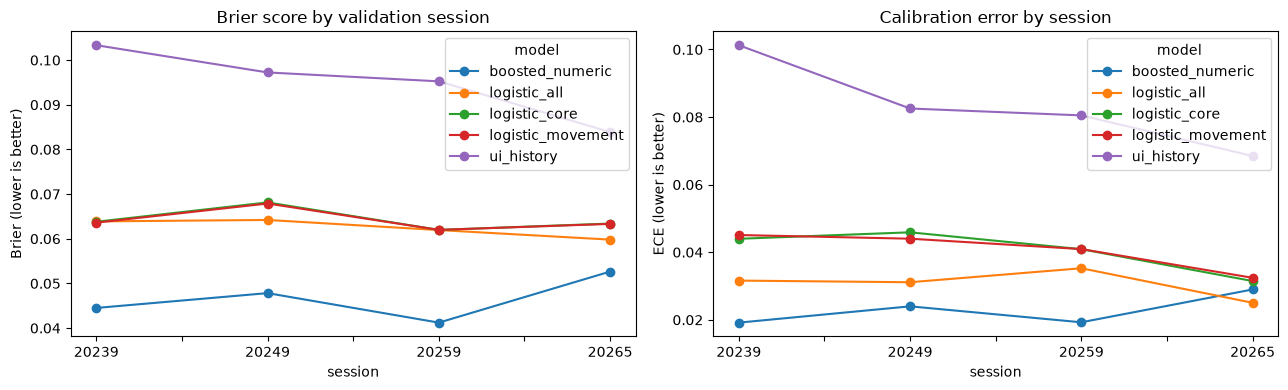

In [5]:
aggregate = scores.groupby('model').agg(
    mean_brier=('brier', 'mean'),
    worst_brier=('brier', 'max'),
    mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'),
    mean_auc=('roc_auc', 'mean'),
).sort_values('mean_brier')
display(aggregate)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
scores.pivot(index='validation_session', columns='model', values='brier').plot(marker='o', ax=axes[0])
axes[0].set(title='Brier score by validation session', ylabel='Brier (lower is better)', xlabel='session')
scores.pivot(index='validation_session', columns='model', values='ece_10').plot(marker='o', ax=axes[1])
axes[1].set(title='Calibration error by session', ylabel='ECE (lower is better)', xlabel='session')
plt.tight_layout()
plt.show()

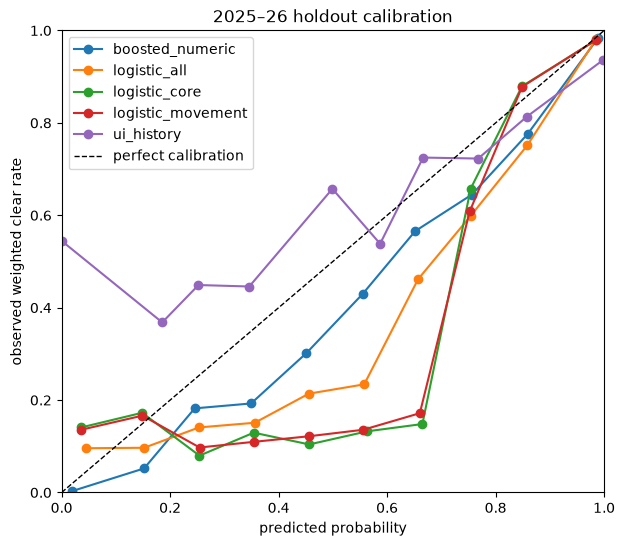

In [6]:
MAIN_HOLDOUT = '20259'
holdout = examples[examples['session'] == MAIN_HOLDOUT].copy()

fig, ax = plt.subplots(figsize=(7, 6))
for model_name in scores.loc[scores['validation_session'] == MAIN_HOLDOUT, 'model']:
    indices, probability = holdout_predictions[(MAIN_HOLDOUT, model_name)]
    frame = examples.loc[indices, ['cleared', 'model_weight']].copy()
    frame['probability'] = probability
    frame['bin'] = pd.cut(frame['probability'], bins=np.linspace(0, 1, 11), include_lowest=True)
    calibration = frame.groupby('bin', observed=True).apply(
        lambda group: pd.Series({
            'predicted': np.average(group['probability'], weights=group['model_weight']),
            'observed': np.average(group['cleared'], weights=group['model_weight']),
        }),
        include_groups=False,
    )
    ax.plot(calibration['predicted'], calibration['observed'], marker='o', label=model_name)
ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1, label='perfect calibration')
ax.set(xlabel='predicted probability', ylabel='observed weighted clear rate', title='2025–26 holdout calibration', xlim=(0, 1), ylim=(0, 1))
ax.legend()
plt.show()

## 5. Findings

All four chronological folds completed on the canonical Notebook 1 cache. Every learned model used the same deterministic training rows within its fold, and all methods were evaluated on the same historical-comparable validation rows.

### Results

- `boosted_numeric` won **all four validation sessions** with **0.0466 mean Brier**, **0.0229 mean ECE**, and **0.9451 mean ROC AUC**.
- `logistic_all` was the strongest logistic candidate with **0.0625 mean Brier**, **0.0308 mean ECE**, and **0.9133 mean ROC AUC**.
- Boosting reduced mean Brier error by **25.5%** relative to `logistic_all` and by **51.0%** relative to the historical percentage.
- Recent movement alone added almost nothing to the compact logistic model: `logistic_movement` and `logistic_core` had mean Brier scores of **0.0642** and **0.0643**.
- Historical-comparison coverage increased from **52.7%** in `20239` to **80.2%** in `20265`.

### Decision

Carry two model families into Notebook 3:

1. `boosted_numeric` as the performance benchmark and current statistical leader.
2. `logistic_all` as the explainable candidate that is straightforward to export into the static browser application.

Notebook 3 must determine whether feature and regularization improvements make logistic regression competitive enough to justify its deployment advantages. If boosting retains a material probability-error advantage, the production architecture should not select logistic regression merely because it is easier to export.
